In [1]:
from pathlib import Path

import netCDF4
import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

In [4]:
# Load the data
ds = xr.open_dataset(
    data / "NextGEMS_EW3_ICON_ngc4008" / "NextGEMS_regridded_hus_025deg_steps_44_45.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["hus"]

In [5]:
eb_abs_qoi = 1e-4  # 1e-6

In [6]:
from numcodecs_wasm_sperr import Sperr

codec = Sperr(mode="psnr", psnr=25)

In [7]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

In [8]:
def differentiate_along_longitude(da: xr.DataArray) -> xr.DataArray:
    da_dXdLon = (da.roll(lon=5) - da.roll(lon=-5)) / (
        da.lon.roll(lon=5) - da.lon.roll(lon=-5)
    )
    da_dXdLon.attrs.update(
        long_name=f"{da.long_name} derivative along longitude",
        units=(f"{da.units} degree**-1" if hasattr(da, "units") else "degree**-1"),
    )
    return da_dXdLon

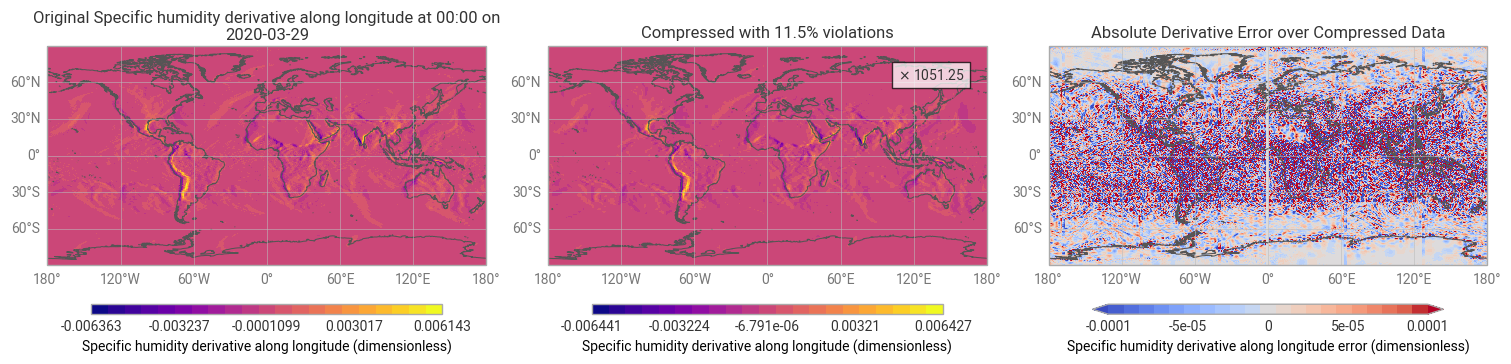

In [9]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

da_deriv = differentiate_along_longitude(da)
da_dec_deriv = differentiate_along_longitude(da_dec)

# violation if
# (a) the absolute error bound over the derivative is exceeded
violations = np.mean(~((da_dec_deriv - da_deriv) <= eb_abs_qoi))
violations = (
    0
    if violations == 0
    else np.format_float_positional(100 * violations, precision=1, min_digits=1) + "%"
)
if violations == "0.0%":
    violations = "<0.05%"

quickplot(da_deriv, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec_deriv,
    fig.add_map(0, 1),
    title=f"Compressed with {violations} violations",
    cr=da.nbytes / np.array(da_enc).nbytes,
)
quickplot(
    (da_dec_deriv - da_deriv).assign_attrs(long_name=f"{da_deriv.long_name} error"),
    fig.add_map(0, 2),
    error=True,
    vrange=(-eb_abs_qoi, eb_abs_qoi),
    title="Absolute Derivative Error over Compressed Data",
)

fig.show()